<a href="https://colab.research.google.com/github/adrygarcia04/Math-BSc/blob/main/Simulaci%C3%B3n_PAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SIMULACIÓN DEL «PASEO ALEATORIO SIMPLE»**

**Autor**: Adrián García Barragán\
**Fecha**: 26/03/2026

## **1. Introducción**

Esta *Jupyter Notebook* en Google Colab se desarrolla en el seno de la asignatura «Procesos Estocásticos», una asignatura optativa del Grado en Matemáticas por la Universidad de Granada. El planteamiento para el curso 2025/2026 de esta asignatura, tiene como uno de sus objetivos transversales desarrollar competencias complementarias a las adquiridas en dicha titulación tales como el lenguaje de programación Python y algunas de sus librerías más útiles para la ciencia de datos y modelización (por ejemplo: *NumPy*, *Matplotlib*, ...).

Concretamente, este archivo es un ejercicio entregable que consiste en realizar simulaciones sobre el proceso estocástico conocido como «paseo aleatorio simple» y documentar el procedimiento de implementación en Python de dicha simulación.

---

## **2. Definición del Paseo Aleatorio Simple**

El paseo aleatorio simple se puede describir formalmente de la siguiente manera:

> Dada una probabilidad $p \in [0,1]$, se define el **paseo aleatorio simple de probabilidad $p$** como $\{X_n\}_{n \in \mathbb{N}}$ tal que $\forall n \in \mathbb{N}, X_n=\sum_{i=1}^nZ_i$ donde $\{Z_i\}_{i \in \mathbb{N}}$ son independientes e idénticamente distribuidas con $P(Z_i=1)=p$ y $P(Z_i=-1)=1-p$ $\forall i \in \mathbb{N}$

Intuitivamente, este proceso se puede comprender como aquel que, empezando en $0$, en cada paso suma o resta $1$ al valor del paso anterior con probabilidad $p$ y $1-p$, respectivamente.

Es conveniente destacar que los $\{Z_i\}_{i \in \mathbb{N}}$ descritos en la definición anterior pueden reescribirse en términos de la distribución de Bernouilli:

> Se tiene que $\{Z_i\}_{i \in \mathbb{N}}=\{2Y_i-1\}_{i \in \mathbb{N}}$ con $\{Y_i\}_{i \in \mathbb{N}}$ una familia de variables aleatorias independientes e identicamente distribuidas $Y_i → B(1,p)$ $\forall i \in \mathbb{N}$

Pese a su sencillez conceptual y de definición, el paseo aleatorio simple goza de características reseñables, tales como ser un «proceso de Markov» para todo valor de $p \in [0,1]$ o ser «martingala» si y solo si $p=0.5$, entre otras. Es por ello que, para complementar su estudio, es interesante realizar distintas simulaciones del paseo aleatorio simple, tal y como pretende este archivo.

---

## **3. Implementación del código de simulación**

### **3.1 Función auxiliar**

En primer lugar, voy a definir una función auxiliar para controlar que la probabilidad introducida en la función de simulación esté en $[0,1]$. Esta comprobación podría implementarse directamente dentro de la función de simulación, pero considero que beneficia para la comprensión de la metodología seguida que desgrane al máximo posible cada etapa.

In [1]:
import sys #Librería necesaria para definir fácilmente los valores por defecto del ínfimo y el supremo.
def dentro_del_intervalo(x,Inf=-sys.float_info.max,Sup=sys.float_info.max,Min=False,Max=False):
  """
  INPUT:
    x (int/float): Número a comprobar si se encuentra en el intervalo.
    Inf (int/float): Ínfimo del intervalo. Por defecto: -1.7976931348623157e+308 (a efectos prácticos -infinito)
    Sup (int/float): Supremo del intervalo. Por defecto: 1.7976931348623157e+308 (a efectos prácticos +infinito)
    Min (bool): ¿El ínfimo es en realidad el mínimo?, es decir, ¿el intervalo se encuentra cerrado por la izquierda? Por defecto: False.
    Max (bool): ¿El supremo es en realidad el máximo?, es decir, ¿el intervalo se encuentra cerrado por la derecha? Por defecto: False.

  OUTPUT:
    output (bool): True si x está en el intervalo y False en caso contrario.
    !!! Devolverá error si el intervalo no está bien definido.
  """

  #Compruebo que el intervalo esté bien definido.
  if Inf>Sup:
    raise ValueError("El intervalo no está bien definido.") #El ínfimo no puede ser estrictamente mayor que el supremo.
  elif Inf==Sup and (not Min or not Max):
    raise ValueError("El intervalo no está bien definido.") #El ínfimo puede ser igual que el supremo si ambos se alcanzan. (Es un intervalo trivial).

  #Defino output como False por defecto y lo convertiré en True si x está en el intervalo.
  output=False

  if Inf<x<Sup:
    output=True #x está estrictamente contenido en el intervalo.
  elif Min and x==Inf:
    output=True #x es el ínfimo y se alcanza el mínimo en el intervalo.
  elif Max and x==Sup:
    output=True #x es el supremo y se alcanza el máximo en el intervalo.

  return output

Tal y como he definido la función auxiliar `dentro_del_intervalo`, comprueba si el número $x$ que le introduzcamos se encuentra en un intervalo o no. Nosotros podemos definir el intervalo en el que queremos que se realice la comprobación, variando el supremo y el ínfimo del mismo, así como si estos se alcanzan o no. Realiza la comprobación de que el intervalo este bien definido. Esta función excede en funcionalidad la comprobación que nos exige la función de simulación, pero ya que pretendía atomizar el desarrollo, la he generalizado en aras de que sea reutilizable.


Los parámetros vienen descritos en el comentario inicial de la función. Por defecto, si no se introducen los parámetros correspondientes al intervalo, he establecido que el intervalo sea $(-1.7976931348623157·10^{308},1.7976931348623157·10^{308})$, lo que en Python es prácticamente equivalente a $(-∞,+∞)$.

### **3.2 Función de simulación**

Una vez definida la función auxiliar, toca abordar la función que simulará los distintos paseos aleatorios simples.

In [2]:
import numpy as np

#Si quisiésemos que fuese reproducible, podríamos fijar una semilla para que la generación de números "aleatoria" sea siempre la misma.

def simular_PAS(p=0.5,n=100,reps=1):
  """
  INPUT:
    p (float): Probabilidad del paseo aleatorio simple. Deberá contener un valor entre 0 y 1 (ambos incluidos).
    n (int): Número de pasos a simular del paseo aleatorio simple de probabilidad «p». Deberá contener un valor mayor (estricto) que 0.
    reps (int): Número simulaciones de trayectorias de «n» pasos del paseo aleatorio simple de probabilidad «p». Deberá contener un valor mayor (estricto) que 0.

  OUTPUT:
    X (numpy.ndarry): Matriz de dimensión «reps» x «n» en la que cada fila será una simulación de una trayectoria de «n» pasos de un paseo aleatorio simple.
    !!! Devolverá error en los siguientes supuestos:
      1. Si la probabilidad «p» no está en el intervalo [0,1].
      2. Si el número de pasos «n» no es un número natural.
      3. Si el número de simulaciones «reps» no es un número natural.
  """

  if not dentro_del_intervalo(p,0,1,True, True):
    raise ValueError("La probabilidad no está en el intervalo [0,1]") #La probabilidad no está en el intervalo [0,1].

  if n<1 or reps<1:
    raise ValueError("El número de pasos y el número de simulaciones deben ser números naturales") #Si alguno de estos valores fuese negativo, np.random.rand() ya nos devolvería un error, pero para el caso en que alguno de los dos es 0 crea un array vacío y tampoco sirve para posteriormente representarlo.

  Z=2*(np.random.rand(reps,n)<p)-1 #La función «np.random.rand()» genera números aleatorios en [0,1) siguiendo una distribución uniforme. Más concretamente, «np.random.rand(reps,n)» nos genera una matriz de dimensión «reps» x «n» de números aleatorios en [0,1) siguiendo una distribución uniforme. Al utilizar la prueba lógica « <p » se nos crea una matriz de dimensión «reps» x «n» de tipo bool que contendría el equivalente a anotar «reps» x «n» realizaciones de una distribución de Bernouilli de probabilidad p. Ya se comentó en el apartado 2 sobre la relación del conjunto Z_i con la distribución de Bernouilli.
  X=np.cumsum(Z, axis=1) #En cada columna de «X» se guarda el valor de la suma acumulada de las columnas de la matriz «Z». Así pues, cada fila contendrá una simulación de una trayectoria de «n» pasos de un paseo aleatorio simple de probabilidad p.

  return X

Tal y como he definido la función `simular_PAS`, genera simulaciones de trayectorias de un paseo aleatorio simple de probabilidad $p$. El usuario puede definir la probabilidad $p \in [0,1]$, el número de pasos que quiere simular así como el número de trayectorias. Por medio de la función `dentro_del_intervalo` realiza la comprobación de que el valor $p$ introducido se encuentre en el intervalo $[0,1]$, que el número de pasos sea un número natural y que el número de trayectorias a simular sea también un número natural.


 Los parámetros vienen descritos en el comentario inicial de la función. Por defecto, si no se introducen los parámetros correspondientes, he establecido que se simule una única trayectoria de $100$ pasos con probabilidad probabilidad $0.5$.

 ---

## **4. Implementación del código de cálculos**

### **4.1 Función de cálculo de la media y la desviación típica teórica**

Es fácilmente demostrable que, la función de medias de un paseo aleatorio simple $E[X_n]=n(2p-1)$ y que su varianza teórica es $Var[X_n]=4np(1-p)$, por lo que en consecuencia la desviación típica teórica es $\sigma_n=2\sqrt{np(1-p)}$.

Las funciones que voy a implementar para calcular la función de medias y la desviación típica teórica harán uso de `simular_PAS`, por lo que también realizarán las mismas comprobaciones sobre los parámetros. Dichos parámetros vendrán descritos en el comentario inicial de la función. Por defecto, si no se introducen los parámetros correspondientes, he fijado $p=0.5$ y $n=100$.

In [3]:
def media_PAS(p=0.5, n=100):
  """
  INPUT:
    p (float): Probabilidad del paseo aleatorio simple. Deberá contener un valor entre 0 y 1 (ambos incluidos).
    n (int): Número de pasos a simular del paseo aleatorio simple de probabilidad «p». Deberá contener un valor mayor (estricto) que 0.

  OUTPUT:
    (numpy.ndarry): Matriz de dimensión «n» x 1 en la que se recoge la función de medias ( n*(2p-1) ).
    !!! Devolverá error en los siguientes supuestos:
      1. Si la probabilidad «p» no está en el intervalo [0,1].
      2. Si el número de pasos «n» no es un número natural.
  """

  if not dentro_del_intervalo(p,0,1,True, True):
    raise ValueError("La probabilidad no está en el intervalo [0,1]") #La probabilidad no está en el intervalo [0,1].

  if n<1:
    raise ValueError("El número de pasos y el número de simulaciones deben ser números naturales") #Si alguno de estos valores fuese negativo, np.random.rand() ya nos devolvería un error, pero para el caso en que alguno de los dos es 0 crea un array vacío y tampoco sirve para posteriormente representarlo.

  return (2*p-1)*np.arange(1,n+1) #En cada fila, contiene el valor (nº de la fila)*(2p-1), luego en cada fila contiene la media correspondiente al paso «nº de la fila».

In [4]:
def desvtip_PAS(p=0.5, n=100):
  """
  INPUT:
    p (float): Probabilidad del paseo aleatorio simple. Deberá contener un valor entre 0 y 1 (ambos incluidos).
    n (int): Número de pasos a simular del paseo aleatorio simple de probabilidad «p». Deberá contener un valor mayor (estricto) que 0.

  OUTPUT:
    (numpy.ndarry): Matriz de dimensión «n» x 1 en la que se recoge la desviación típica ( 4*n*p*(1-p) ).
    !!! Devolverá error en los siguientes supuestos:
      1. Si la probabilidad «p» no está en el intervalo [0,1].
      2. Si el número de pasos «n» no es un número natural.
  """

  if not dentro_del_intervalo(p,0,1,True, True):
    raise ValueError("La probabilidad no está en el intervalo [0,1]") #La probabilidad no está en el intervalo [0,1].

  if n<1:
    raise ValueError("El número de pasos y el número de simulaciones deben ser números naturales") #Si alguno de estos valores fuese negativo, np.random.rand() ya nos devolvería un error, pero para el caso en que alguno de los dos es 0 crea un array vacío y tampoco sirve para posteriormente representarlo.

  return (4*p*(1-p)*np.arange(1,n+1))**(1/2) #En cada fila, contiene la raíz cuadrada del valor 4*(nº de la fila)*p*(1-p), luego en cada fila contiene la desviación típica correspondiente al paso «nº de la fila».

### **4.2 Función de cálculo de la media empírica**



In [5]:
def media_emp_PAS(p=0.5, n=100, reps=5):
  """
  INPUT:
    p (float): Probabilidad del paseo aleatorio simple. Deberá contener un valor entre 0 y 1 (ambos incluidos).
    n (int): Número de pasos a simular del paseo aleatorio simple de probabilidad «p». Deberá contener un valor mayor (estricto) que 0.
    reps (int): Número simulaciones de trayectorias de «n» pasos del paseo aleatorio simple de probabilidad «p». Deberá contener un valor mayor (estricto) que 0.

  OUTPUT:
    (numpy.ndarry): Matriz de dimensión «n» x 1 que contiene la media empírica de de «reps» trayectorias del paseo aleatorio simple de probabilidad «p».
    !!! Devolverá error en los siguientes supuestos:
      1. Si la probabilidad «p» no está en el intervalo [0,1].
      2. Si el número de pasos «n» no es un número natural.
      3. Si el número de simulaciones «reps» no es un número natural.
  """
  return np.mean(simular_PAS(p,n,reps), axis=0)


La función calcula la media empírica de un número de trayectorias de $n$ pasos. Como recurre a `simular_PAS` hace las mismas comprobaciones sobre los parámetros. Dichos parámetros vendrán descritos en el comentario inicial de la función. Por defecto, si no se introducen los parámetros correspondientes, he establecido $p=0.5$ y $n=100$.

---


## **5. Implementación del código de visualización**

Una vez implementado todo el código que simula los distintos aspectos del paseo aleatorio simple que pretendíamos estudiar, solo queda visualizar dichas simulaciones y comprobar que, efectivamente, los resultados teóricos coinciden con las realizaciones empíricas.

#### **5.1 Visualización de las simulaciones de paseos aleatorios simples (sin media ni desviación típica teórica)**

La simulación de $5$ trayectorias de $500$ pasos de un paseo aleatorio simple de $p=0.5$ es:

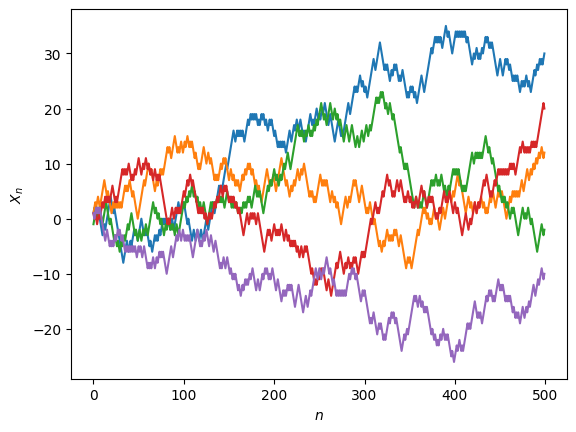

In [16]:
from matplotlib import pyplot as plt

plt.plot(np.transpose(simular_PAS(n=500,reps=5)))

plt.xlabel("$n$") #Etiqueta al eje x.
plt.ylabel("$X_n$") #Etiqueta al eje y.

plt.show()

Cabe apreciar que esta simulación coincide con la intución y los resultados teóricos, ya que sin demasiada reflexión se puede concluir que las trayectorias deberían quedarse en torno al $0$ (la media para $p=0.5$) y no debería haber tendencias crecientes o decrecientes de las trayectorias.

En contraposición, la simulación de $5$ trayectorias de $500$ pasos de un paseo aleatorio simple de $p=0.6$ es:

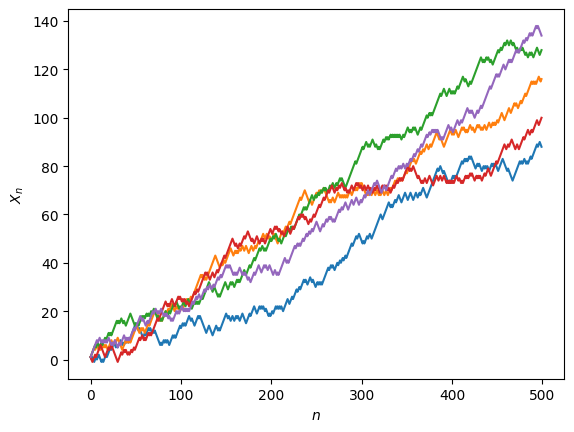

In [ ]:
plt.plot(np.transpose(simular_PAS(0.6,500,5)))

plt.xlabel("$n$") #Etiqueta al eje x.
plt.ylabel("$X_n$") #Etiqueta al eje y.

plt.show()

Y la simulación de $5$ trayectorias de $500$ pasos de un paseo aleatorio simple de $p=0.6$ es:

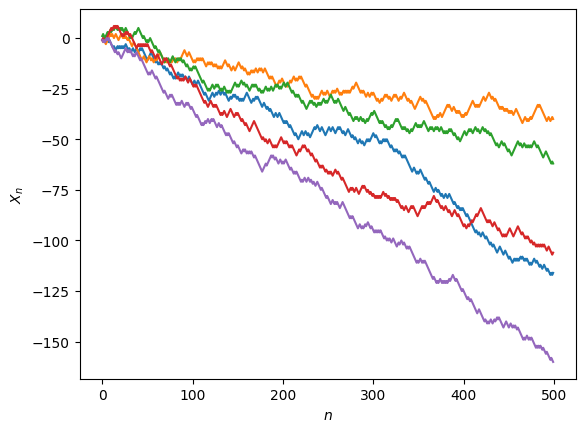

In [ ]:
plt.plot(np.transpose(simular_PAS(0.4,500,5)))

plt.xlabel("$n$") #Etiqueta al eje x.
plt.ylabel("$X_n$") #Etiqueta al eje y.

plt.show()

Las cuales coinciden también con la intuición y los resultados teóricos ya que las trayectorias también oscilan aproximadamente alrededor de las medias, y se observa la tendencia creciente en la de $p=0.6$ y la decreciente en la de $p=0.4$.

#### **5.2 Visualización de las simulaciones de paseos aleatorios simples (con media y desviación típica teórica)**

Para realizar una visualización aún más interesante, podemos graficar también la función de medias y un entorno proporcional a la desviación típica alrededor de la media (algo interesante de representar por la «desigualdad de Chebychev»).

> Dado $\{X_n\}_{n \in \mathbb{N}}$ un proceso estocástico de varianza finita, la **desigualdad de Chebychev** nos asegura que $\forall n \in \mathbb{N}$, $P(|X_n - E[X_n]| \geq k\sigma_n ) \geq 1-\frac{1}{k^2}$

Es decir, en virtud de la desigualdad de Chebychev, al menos el $100·(1-\frac{1}{k^2}) \%$ de las trayectorias estarán en el intervalo $(E[X_n]-k\sigma_n,E[X_n]+k\sigma_n)$.

La visualización en las condiciones anteriormente descritas de $20$ trayectorias de $500$ pasos de un paseo aleatorio simple de probabilidad $p=0.5$ es:

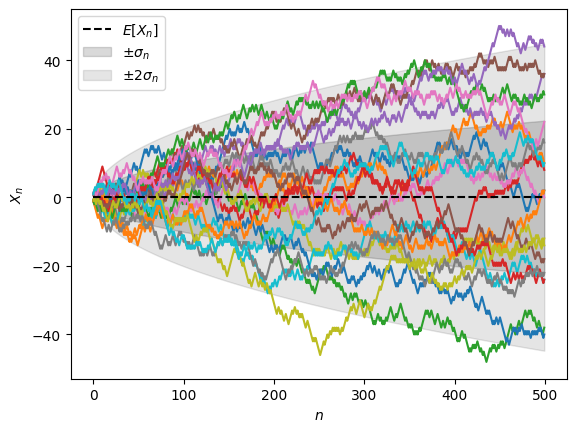

In [ ]:
Ex=media_PAS(n=500)
Sx=desvtip_PAS(n=500)

plt.plot(np.transpose(simular_PAS(n=500,reps=20)))
plt.plot(Ex, label="$E[X_n]$", linestyle="--", color="black") #Media teórica. Le ponemos etiqueta para que se muestre en la leyenda, establecemos su color y su estilo de línea discontinuo.
plt.fill_between(x=list(range(0,500)), y1=Ex+Sx, y2=Ex-Sx, label=r"$\pm\sigma_n$", color='black', alpha=0.15) #Región entre y1=(media teórica + desviación típica) e y2=(media teórica - desviación típica). Le ponemos etiqueta (indicando que va a contener caracteres extraños para evitar los warnings) para que se muestre en la leyenda, establecemos su color y disminuimos su opacidad al 15%.
plt.fill_between(x=list(range(0,500)), y1=Ex+2*Sx, y2=Ex-2*Sx, label=r"$\pm2\sigma_n$", color='black', alpha=0.1) #Región entre y1=(media teórica + 2*desviación típica) e y2=(media teórica - 2*desviación típica). Le ponemos etiqueta (indicando que va a contener caracteres extraños para evitar los warnings) para que se muestre en la leyenda, establecemos su color y disminuimos su opacidad al 10%.

plt.xlabel("$n$") #Etiqueta al eje x.
plt.ylabel("$X_n$") #Etiqueta al eje y.

plt.legend(loc="upper left") #Leyenda.

plt.show()

La visualización en las condiciones anteriormente descritas de $5$  trayectorias de $500$ pasos de un paseo aleatorio simple de probabilidad $p=0.75$ es:

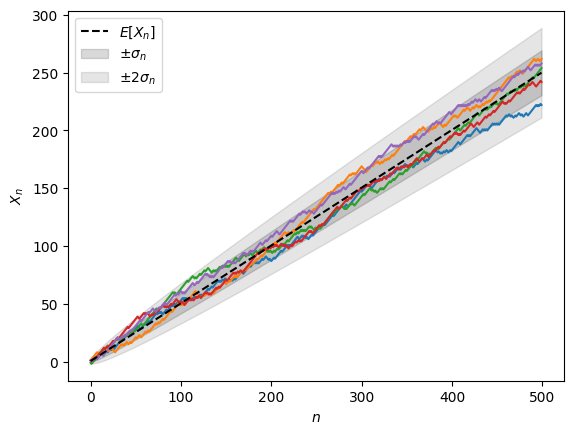

In [ ]:
Ex=media_PAS(0.75,500)
Sx=desvtip_PAS(0.75,500)

plt.plot(np.transpose(simular_PAS(0.75,500,5)))
plt.plot(Ex, label="$E[X_n]$", linestyle="--", color="black") #Media teórica. Le ponemos etiqueta para que se muestre en la leyenda, establecemos su color y su estilo de línea discontinuo.
plt.fill_between(x=list(range(0,500)), y1=Ex+Sx, y2=Ex-Sx, label=r"$\pm\sigma_n$", color='black', alpha=0.15) #Región entre y1=(media teórica + desviación típica) e y2=(media teórica - desviación típica). Le ponemos etiqueta (indicando que va a contener caracteres extraños para evitar los warnings) para que se muestre en la leyenda, establecemos su color y disminuimos su opacidad al 15%.
plt.fill_between(x=list(range(0,500)), y1=Ex+2*Sx, y2=Ex-2*Sx, label=r"$\pm2\sigma_n$", color='black', alpha=0.1) #Región entre y1=(media teórica + 2*desviación típica) e y2=(media teórica - 2*desviación típica). Le ponemos etiqueta (indicando que va a contener caracteres extraños para evitar los warnings) para que se muestre en la leyenda, establecemos su color y disminuimos su opacidad al 10%.

plt.xlabel("$n$") #Etiqueta al eje x.
plt.ylabel("$X_n$") #Etiqueta al eje y.

plt.legend(loc="upper left") #Leyenda.

plt.show()

Y la visualización en las condiciones anteriormente descritas de $5$  trayectorias de $500$ pasos de un paseo aleatorio simple de probabilidad $p=0.95$ es:

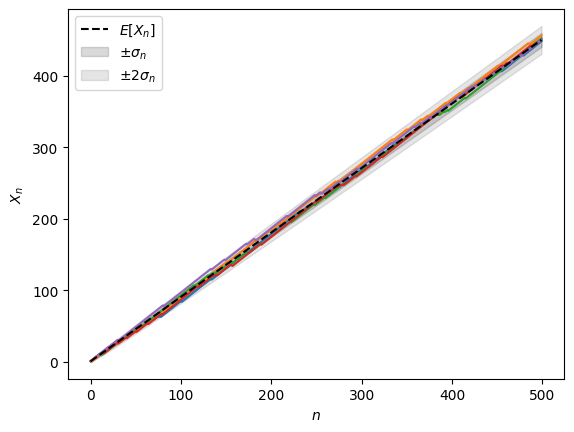

In [ ]:
Ex=media_PAS(0.95,500)
Sx=desvtip_PAS(0.95,500)

plt.plot(np.transpose(simular_PAS(0.95,500,5)))
plt.plot(Ex, label="$E[X_n]$", linestyle="--", color="black") #Media teórica. Le ponemos etiqueta para que se muestre en la leyenda, establecemos su color y su estilo de línea discontinuo.
plt.fill_between(x=list(range(0,500)), y1=Ex+Sx, y2=Ex-Sx, label=r"$\pm\sigma_n$", color='black', alpha=0.15) #Región entre y1=(media teórica + desviación típica) e y2=(media teórica - desviación típica). Le ponemos etiqueta (indicando que va a contener caracteres extraños para evitar los warnings) para que se muestre en la leyenda, establecemos su color y disminuimos su opacidad al 15%.
plt.fill_between(x=list(range(0,500)), y1=Ex+2*Sx, y2=Ex-2*Sx, label=r"$\pm2\sigma_n$", color='black', alpha=0.1) #Región entre y1=(media teórica + 2*desviación típica) e y2=(media teórica - 2*desviación típica). Le ponemos etiqueta (indicando que va a contener caracteres extraños para evitar los warnings) para que se muestre en la leyenda, establecemos su color y disminuimos su opacidad al 10%.

plt.xlabel("$n$") #Etiqueta al eje x.
plt.ylabel("$X_n$") #Etiqueta al eje y.

plt.legend(loc="upper left") #Leyenda.

plt.show()

En todas estas visualizaciones se puede apreciar que se cumple sobradamente la cota mínima que establece la desigualdad de Chebychev, ya que dicha cota es bastante burda al no utilizar propiedades más características de la variable.

#### **5.3 Visualización de media empírica cuando aumentamos el número de trayectorias**

Una última visualización interesante es la de ver cómo las medias empíricas se van aproximando a la media teórica en función que se aumentan el número de trayectorias.

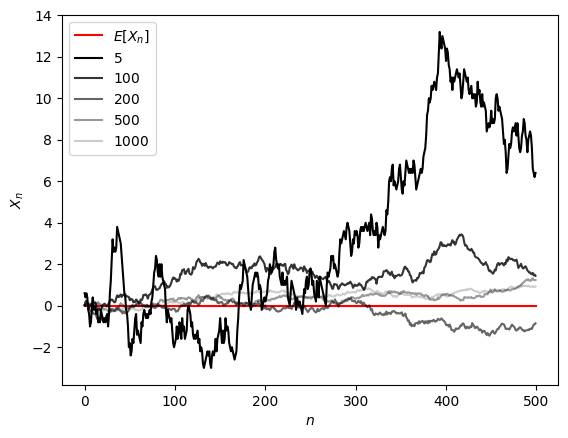

In [21]:
plt.plot(media_PAS(n=500), label="$E[X_n]$", color="red") #Media teórica. Le ponemos etiqueta para que se muestre en la leyenda, establecemos su color.
plt.plot(media_emp_PAS(n=500, reps=5), label="$5$", color="black") #Media empírica de 5 trayectorias. Le ponemos etiqueta para que se muestre en la leyenda, establecemos su color.
plt.plot(media_emp_PAS(n=500, reps=100), label="$100$", color="black", alpha=0.8) #Media empírica de 100 trayectorias. Le ponemos etiqueta para que se muestre en la leyenda, establecemos su color y disminuimos su opacidad al 80%.
plt.plot(media_emp_PAS(n=500, reps=200), label="$200$", color="black", alpha=0.6) #Media empírica de 200 trayectorias. Le ponemos etiqueta para que se muestre en la leyenda, establecemos su color y disminuimos su opacidad al 60%.
plt.plot(media_emp_PAS(n=500, reps=500), label="$500$", color="black", alpha=0.4) #Media empírica de 500 trayectorias. Le ponemos etiqueta para que se muestre en la leyenda, establecemos su color y disminuimos su opacidad al 40%.
plt.plot(media_emp_PAS(n=500, reps=1000), label="$1000$", color="black", alpha=0.2) #Media empírica de 1000 trayectorias. Le ponemos etiqueta para que se muestre en la leyenda, establecemos su color y disminuimos su opacidad al 20%.

plt.xlabel("$n$") #Etiqueta al eje x.
plt.ylabel("$X_n$") #Etiqueta al eje y.

plt.legend(loc="upper left") #Leyenda

plt.show()